In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Reproducibility
np.random.seed(42)
random.seed(42)

print("Libraries loaded")

Libraries loaded


In [2]:
# Facility profiles based on real wood finishing
# chemical plant parameters

FACILITIES = {
    'A': {
        'name': 'Facility A — Well Run',
        'naics': 325510,
        'employees': 120,
        'ppe_compliance_rate': 0.92,
        'reporting_culture': 0.85,
        'maintenance_quality': 0.90,
        'avg_tenure_days': 1095,
        'turnover_rate': 0.15,
        'base_pressure': 3.0,
        'overtime_frequency': 0.10,
        'supervisor_coverage': 0.85,
    },
    'B': {
        'name': 'Facility B — Elevated Risk',
        'naics': 325510,
        'employees': 95,
        'ppe_compliance_rate': 0.61,
        'reporting_culture': 0.40,
        'maintenance_quality': 0.55,
        'avg_tenure_days': 240,
        'turnover_rate': 0.45,
        'base_pressure': 7.0,
        'overtime_frequency': 0.35,
        'supervisor_coverage': 0.55,
    }
}

ROLES = ['mixer', 'filler', 'loader',
         'maintenance', 'quality_control',
         'line_supervisor']

HAZARD_TYPES = ['slip_fall', 'chemical_splash',
                'repetitive_motion', 'burn']

print("Facility profiles configured")
print(f"Facility A employees: {FACILITIES['A']['employees']}")
print(f"Facility B employees: {FACILITIES['B']['employees']}")

Facility profiles configured
Facility A employees: 120
Facility B employees: 95


In [3]:
def generate_workforce(facility_id, config):
    workers = []
    for i in range(config['employees']):

        # Tenure based on facility profile
        tenure = max(30, int(np.random.exponential(
            config['avg_tenure_days'])))

        # Training currency degrades with tenure gap
        days_since_training = np.random.randint(0, 365)
        training_current = 1 if days_since_training < 180 else 0

        role = np.random.choice(
            ROLES,
            p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]
        )

        workers.append({
            'worker_id': f"{facility_id}_{i:04d}",
            'facility_id': facility_id,
            'role': role,
            'tenure_days': tenure,
            'training_current': training_current,
            'days_since_training': days_since_training,
        })

    return pd.DataFrame(workers)

workforce_a = generate_workforce('A', FACILITIES['A'])
workforce_b = generate_workforce('B', FACILITIES['B'])

print(f"Facility A workforce: {len(workforce_a)}")
print(f"Facility B workforce: {len(workforce_b)}")
print(f"\nRole distribution A:")
print(workforce_a['role'].value_counts())

Facility A workforce: 120
Facility B workforce: 95

Role distribution A:
role
filler             40
loader             27
mixer              24
maintenance        12
quality_control    12
line_supervisor     5
Name: count, dtype: int64


In [4]:
def generate_shifts(facility_id, config,
                    workforce, days=365):

    records = []
    start_date = datetime(2024, 1, 1)

    for day in range(days):
        current_date = start_date + timedelta(days=day)
        month = current_date.month
        day_of_week = current_date.weekday() + 1

        # Seasonal pressure — Q4 higher production
        seasonal_multiplier = 1.3 if month in [10,11,12] else 1.0

        # Friday fatigue effect
        fatigue_multiplier = 1.2 if day_of_week == 5 else 1.0

        for shift in [1, 2, 3]:

            # Night shift elevated risk
            shift_multiplier = 1.3 if shift == 3 else 1.0

            # Staffing level varies
            staffing = np.random.normal(0.90, 0.08)
            staffing = np.clip(staffing, 0.60, 1.0)

            # Production pressure
            pressure = min(10, config['base_pressure'] *
                         seasonal_multiplier +
                         np.random.normal(0, 1.5))

            # Supervisor present
            supervisor = 1 if np.random.random() < (
                config['supervisor_coverage'] /
                shift_multiplier) else 0

            # Sample workers on this shift
            shift_workers = workforce.sample(
                n=max(10, int(
                    len(workforce) * 0.33 * staffing)),
                replace=False
            )

            for _, worker in shift_workers.iterrows():

                # Overtime flag
                overtime = 1 if np.random.random() < (
                    config['overtime_frequency'] *
                    seasonal_multiplier) else 0

                # Hours into shift at incident window
                hours_into_shift = np.random.randint(1, 13)

                # Floor condition
                floor = np.random.choice(
                    [0, 1, 2],
                    p=[0.70, 0.20, 0.10]
                ) if config['maintenance_quality'] > 0.7 else \
                    np.random.choice(
                    [0, 1, 2],
                    p=[0.40, 0.35, 0.25]
                )

                # Equipment status
                equip = np.random.choice(
                    [0, 1, 2],
                    p=[0.80, 0.15, 0.05]
                ) if config['maintenance_quality'] > 0.7 else \
                    np.random.choice(
                    [0, 1, 2],
                    p=[0.45, 0.30, 0.25]
                )

                # PPE compliance
                ppe = 1 if np.random.random() < \
                    config['ppe_compliance_rate'] else 0

                # Temperature varies by season
                temp = np.random.normal(
                    22 + (3 if month in [6,7,8] else 0),
                    3)

                records.append({
                    'facility_id': facility_id,
                    'date': current_date.strftime('%Y-%m-%d'),
                    'month': month,
                    'day_of_week': day_of_week,
                    'shift': shift,
                    'worker_id': worker['worker_id'],
                    'role': worker['role'],
                    'tenure_days': worker['tenure_days'],
                    'training_current':
                        worker['training_current'],
                    'days_since_training':
                        worker['days_since_training'],
                    'overtime_flag': overtime,
                    'hours_into_shift': hours_into_shift,
                    'production_pressure': round(pressure, 2),
                    'supervisor_present': supervisor,
                    'staffing_level': round(staffing, 2),
                    'floor_condition': floor,
                    'equipment_status': equip,
                    'temp_celsius': round(temp, 1),
                    'ppe_compliant': ppe,
                })

    return pd.DataFrame(records)

print("Generating Facility A shifts...")
shifts_a = generate_shifts('A', FACILITIES['A'],
                            workforce_a, days=365)
print(f"Facility A records: {len(shifts_a):,}")

print("Generating Facility B shifts...")
shifts_b = generate_shifts('B', FACILITIES['B'],
                            workforce_b, days=365)
print(f"Facility B records: {len(shifts_b):,}")

Generating Facility A shifts...
Facility A records: 38,284
Generating Facility B shifts...
Facility B records: 30,084


In [5]:
def assign_incidents_v2(df, config):

    df = df.copy()
    near_miss_flags = []
    near_miss_types = []
    near_miss_reported = []
    injury_flags = []
    injury_types = []
    severities = []

    for _, row in df.iterrows():

        # Start with base risk
        risk = 0.03

        # ─── KNOWLEDGE LAYER ─────────────────
        # New hire + no training = sharp risk jump
        if row['tenure_days'] < 90 and \
           row['training_current'] == 0:
            risk *= 3.5  # multiplicative
        elif row['tenure_days'] < 90:
            risk *= 1.8
        elif row['training_current'] == 0:
            risk *= 1.5

        if row['days_since_training'] > 270:
            risk *= 1.4

        # ─── DECISION LAYER ──────────────────
        # PPE failure is a major risk multiplier
        if row['ppe_compliant'] == 0:
            risk *= 2.8

        # Production pressure compounds
        if row['production_pressure'] > 7:
            risk *= 1.8
        elif row['production_pressure'] > 5:
            risk *= 1.3

        # Overtime + no supervisor = danger zone
        if row['overtime_flag'] == 1 and \
           row['supervisor_present'] == 0:
            risk *= 2.2
        elif row['overtime_flag'] == 1:
            risk *= 1.4

        # ─── SITUATIONAL LAYER ───────────────
        # Late shift fatigue
        if row['hours_into_shift'] > 10:
            risk *= 1.7
        elif row['hours_into_shift'] > 8:
            risk *= 1.3

        # Floor and equipment failures
        if row['floor_condition'] == 2:
            risk *= 1.6
        elif row['floor_condition'] == 1:
            risk *= 1.2

        if row['equipment_status'] == 2:
            risk *= 1.8
        elif row['equipment_status'] == 1:
            risk *= 1.3

        # Night shift compounding
        if row['shift'] == 3:
            risk *= 1.3

        # ─── ROLE-BASED EXPOSURE ─────────────
        # Chemical-facing roles
        if row['role'] in ['mixer', 'filler']:
            risk *= 1.6
        elif row['role'] == 'maintenance':
            risk *= 1.4

        # ─── CRITICAL INTERACTION ────────────
        # Chemical exposure scenario
        # No PPE + chemical role + production pressure
        if row['role'] in ['mixer', 'filler'] and \
           row['ppe_compliant'] == 0 and \
           row['production_pressure'] > 6:
            risk *= 2.5

        # Cap risk
        risk = min(risk, 0.55)

        # Near miss occurs
        near_miss = 1 if np.random.random() < risk else 0

        # Hazard type
        if near_miss:
            if row['role'] in ['mixer', 'filler']:
                weights = [0.15, 0.55, 0.15, 0.15]
            elif row['role'] == 'loader':
                weights = [0.45, 0.15, 0.25, 0.15]
            elif row['role'] == 'maintenance':
                weights = [0.15, 0.20, 0.20, 0.45]
            else:
                weights = [0.30, 0.25, 0.30, 0.15]

            nm_type = np.random.choice(
                HAZARD_TYPES, p=weights)
        else:
            nm_type = None

        # Reporting
        if near_miss:
            reported = 1 if np.random.random() < \
                config['reporting_culture'] else 0
        else:
            reported = 0

        # Injury escalation — sharper now
        if near_miss:
            if row['ppe_compliant'] == 0:
                injury_prob = 0.35  # was 0.18
            else:
                injury_prob = 0.18  # was 0.08
        else:
            injury_prob = 0.005

        injury = 1 if np.random.random() < \
            injury_prob else 0

        injury_type = nm_type if injury else None

        # Severity
        if injury:
            if row['ppe_compliant'] == 0 and \
               nm_type == 'chemical_splash':
                sev = np.random.choice(
                    [2, 3, 4], p=[0.25, 0.45, 0.30])
            elif nm_type == 'burn':
                sev = np.random.choice(
                    [2, 3, 4], p=[0.35, 0.40, 0.25])
            else:
                sev = np.random.choice(
                    [1, 2, 3], p=[0.40, 0.45, 0.15])
        else:
            sev = 0

        near_miss_flags.append(near_miss)
        near_miss_types.append(nm_type)
        near_miss_reported.append(reported)
        injury_flags.append(injury)
        injury_types.append(injury_type)
        severities.append(sev)

    df['near_miss_flag'] = near_miss_flags
    df['near_miss_type'] = near_miss_types
    df['near_miss_reported'] = near_miss_reported
    df['injury_flag'] = injury_flags
    df['injury_type'] = injury_types
    df['severity'] = severities

    return df

print("Regenerating Facility A incidents...")
sim_a = assign_incidents_v2(shifts_a, FACILITIES['A'])

print("Regenerating Facility B incidents...")
sim_b = assign_incidents_v2(shifts_b, FACILITIES['B'])

# Recombine
sim_full = pd.concat([sim_a, sim_b], ignore_index=True)

print(f"\nNew injury rate by facility:")
print(sim_full.groupby('facility_id')
      ['injury_flag'].mean().round(4))

print(f"\nNew near miss rate by facility:")
print(sim_full.groupby('facility_id')
      ['near_miss_flag'].mean().round(4))

print(f"\nInjury counts:")
print(sim_full.groupby('facility_id')
      ['injury_flag'].sum())

Regenerating Facility A incidents...
Regenerating Facility B incidents...

New injury rate by facility:
facility_id
A    0.0325
B    0.0997
Name: injury_flag, dtype: float64

New near miss rate by facility:
facility_id
A    0.1283
B    0.3523
Name: near_miss_flag, dtype: float64

Injury counts:
facility_id
A    1244
B    3000
Name: injury_flag, dtype: int64


In [6]:
# Combine both facilities
sim_full = pd.concat([sim_a, sim_b],
                      ignore_index=True)

print(f"Total records: {len(sim_full):,}")
print(f"\nFacility distribution:")
print(sim_full['facility_id'].value_counts())

print(f"\nNear miss rate by facility:")
print(sim_full.groupby('facility_id')
      ['near_miss_flag'].mean().round(4))

print(f"\nInjury rate by facility:")
print(sim_full.groupby('facility_id')
      ['injury_flag'].mean().round(4))

print(f"\nNear miss type distribution:")
print(sim_full[sim_full['near_miss_flag']==1]
      ['near_miss_type'].value_counts())

print(f"\nReporting rate by facility:")
nm_only = sim_full[sim_full['near_miss_flag']==1]
print(nm_only.groupby('facility_id')
      ['near_miss_reported'].mean().round(4))

print(f"\nInjury by role:")
print(sim_full.groupby('role')
      ['injury_flag'].mean().round(4)
      .sort_values(ascending=False))

Total records: 68,368

Facility distribution:
facility_id
A    38284
B    30084
Name: count, dtype: int64

Near miss rate by facility:
facility_id
A    0.1283
B    0.3523
Name: near_miss_flag, dtype: float64

Injury rate by facility:
facility_id
A    0.0325
B    0.0997
Name: injury_flag, dtype: float64

Near miss type distribution:
near_miss_type
chemical_splash      5864
slip_fall            3488
repetitive_motion    3111
burn                 3046
Name: count, dtype: int64

Reporting rate by facility:
facility_id
A    0.8481
B    0.3943
Name: near_miss_reported, dtype: float64

Injury by role:
role
mixer              0.0701
maintenance        0.0700
filler             0.0648
line_supervisor    0.0598
loader             0.0558
quality_control    0.0413
Name: injury_flag, dtype: float64


In [7]:
# Save to CSV
sim_full.to_csv('wips_synthetic_facility_data.csv',
                index=False)

print(f"Saved: wips_synthetic_facility_data.csv")
print(f"Records: {len(sim_full):,}")
print(f"Columns: {len(sim_full.columns)}")
print(f"\nColumn list:")
print(list(sim_full.columns))

Saved: wips_synthetic_facility_data.csv
Records: 68,368
Columns: 25

Column list:
['facility_id', 'date', 'month', 'day_of_week', 'shift', 'worker_id', 'role', 'tenure_days', 'training_current', 'days_since_training', 'overtime_flag', 'hours_into_shift', 'production_pressure', 'supervisor_present', 'staffing_level', 'floor_condition', 'equipment_status', 'temp_celsius', 'ppe_compliant', 'near_miss_flag', 'near_miss_type', 'near_miss_reported', 'injury_flag', 'injury_type', 'severity']


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# Features available BEFORE the incident occurs
# Critical — no leakage from outcome columns
features = [
    'facility_id',        # which facility
    'month',              # seasonal
    'day_of_week',
    'shift',
    'role',
    'tenure_days',
    'training_current',
    'days_since_training',
    'overtime_flag',
    'hours_into_shift',
    'production_pressure',
    'supervisor_present',
    'staffing_level',
    'floor_condition',
    'equipment_status',
    'temp_celsius',
    'ppe_compliant',
]

# Target — did an injury occur on this shift
target = 'injury_flag'

X = sim_full[features].copy()
y = sim_full[target].copy()

# Encode categorical columns
le_facility = LabelEncoder()
le_role = LabelEncoder()
X['facility_id'] = le_facility.fit_transform(X['facility_id'])
X['role'] = le_role.fit_transform(X['role'])

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(y.value_counts(normalize=True).round(4))

Feature matrix: (68368, 17)
Target distribution:
injury_flag
0    64124
1     4244
Name: count, dtype: int64

Class balance:
injury_flag
0    0.9379
1    0.0621
Name: proportion, dtype: float64


In [9]:
# Train test split — stratified on outcome
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training: {X_train.shape}")
print(f"Test: {X_test.shape}")

# Train Random Forest with class balancing
# Critical because injuries are rare
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No Injury', 'Injury'],
    digits=3
))

Training: (54694, 17)
Test: (13674, 17)

Training model...

Classification Report:
              precision    recall  f1-score   support

   No Injury      0.943     0.966     0.955     12825
      Injury      0.187     0.117     0.144       849

    accuracy                          0.914     13674
   macro avg      0.565     0.542     0.549     13674
weighted avg      0.896     0.914     0.904     13674



In [10]:
# Which features actually drove predictions
importances = pd.Series(
    clf.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(importances.round(4))

# Check the three layers you identified
knowledge_features = ['training_current',
                       'days_since_training',
                       'tenure_days']
decision_features = ['ppe_compliant',
                     'supervisor_present',
                     'overtime_flag',
                     'production_pressure']
situational_features = ['hours_into_shift',
                        'floor_condition',
                        'equipment_status',
                        'shift']

print(f"\nKnowledge layer total importance: "
      f"{importances[knowledge_features].sum():.4f}")
print(f"Decision layer total importance:  "
      f"{importances[decision_features].sum():.4f}")
print(f"Situational layer total importance: "
      f"{importances[situational_features].sum():.4f}")

Feature Importance:
ppe_compliant          0.1382
production_pressure    0.1275
temp_celsius           0.1035
tenure_days            0.0951
days_since_training    0.0870
staffing_level         0.0796
hours_into_shift       0.0660
month                  0.0618
day_of_week            0.0499
facility_id            0.0391
role                   0.0355
equipment_status       0.0264
floor_condition        0.0261
shift                  0.0254
overtime_flag          0.0156
supervisor_present     0.0143
training_current       0.0091
dtype: float64

Knowledge layer total importance: 0.1912
Decision layer total importance:  0.2955
Situational layer total importance: 0.1439


In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

# AUC tells us how well the model ranks risk
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"ROC AUC: {auc:.4f}")
print(f"Average Precision: {ap:.4f}")

# Risk score distribution
print(f"\nPredicted risk by actual outcome:")
results = pd.DataFrame({
    'actual': y_test.values,
    'risk_score': y_proba
})
print(results.groupby('actual')['risk_score']
      .describe().round(4))

ROC AUC: 0.7239
Average Precision: 0.1469

Predicted risk by actual outcome:
          count    mean     std     min     25%     50%     75%     max
actual                                                                 
0       12825.0  0.1668  0.1273  0.0101  0.0797  0.1243  0.2003  0.7278
1         849.0  0.2861  0.1619  0.0153  0.1387  0.2706  0.4173  0.7029


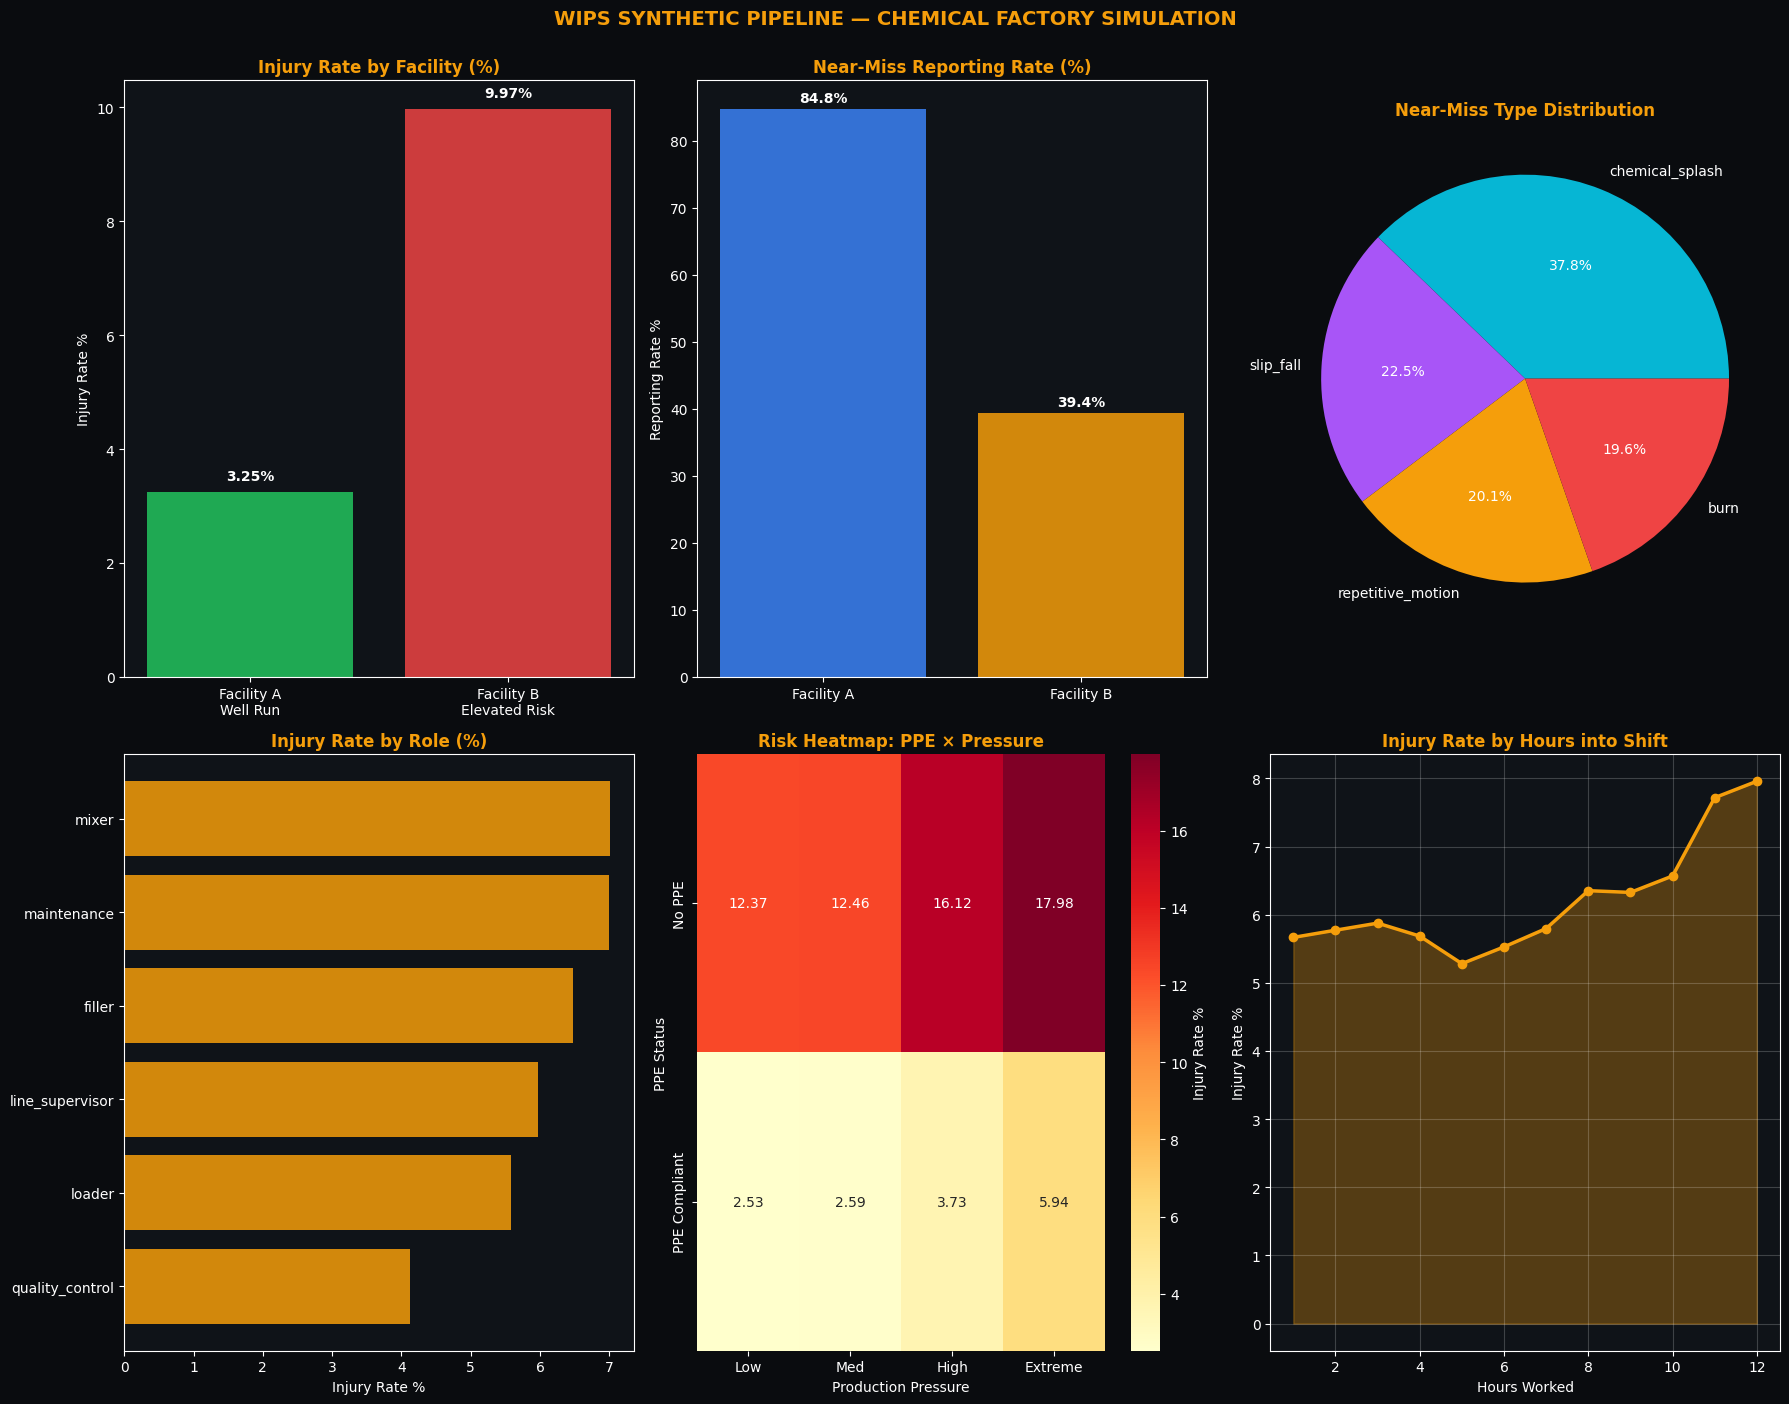

Saved: wips_synthetic_pipeline.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dark style matching your preflight charts
plt.style.use('dark_background')
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0a0c0f')

# ── CHART 1 ─ Injury Rate by Facility ─────
ax1 = fig.add_subplot(2, 3, 1)
facility_injury = sim_full.groupby('facility_id')[
    'injury_flag'].mean() * 100
colors1 = ['#22c55e', '#ef4444']
bars = ax1.bar(['Facility A\nWell Run',
                'Facility B\nElevated Risk'],
               facility_injury.values,
               color=colors1, alpha=0.85)
ax1.set_title('Injury Rate by Facility (%)',
              color='#f59e0b', fontweight='bold')
ax1.set_ylabel('Injury Rate %', color='white')
for bar, val in zip(bars, facility_injury.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + 0.2, f'{val:.2f}%',
             ha='center', color='white',
             fontweight='bold')
ax1.set_facecolor('#0f1318')

# ── CHART 2 ─ Reporting Culture Gap ───────
ax2 = fig.add_subplot(2, 3, 2)
nm_only = sim_full[sim_full['near_miss_flag']==1]
reporting = nm_only.groupby('facility_id')[
    'near_miss_reported'].mean() * 100
bars = ax2.bar(['Facility A', 'Facility B'],
               reporting.values,
               color=['#3b82f6', '#f59e0b'],
               alpha=0.85)
ax2.set_title('Near-Miss Reporting Rate (%)',
              color='#f59e0b', fontweight='bold')
ax2.set_ylabel('Reporting Rate %', color='white')
for bar, val in zip(bars, reporting.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + 1, f'{val:.1f}%',
             ha='center', color='white',
             fontweight='bold')
ax2.set_facecolor('#0f1318')

# ── CHART 3 ─ Hazard Type Distribution ────
ax3 = fig.add_subplot(2, 3, 3)
hazard_counts = sim_full[
    sim_full['near_miss_flag']==1]['near_miss_type'].value_counts()
colors3 = ['#06b6d4', '#a855f7', '#f59e0b', '#ef4444']
ax3.pie(hazard_counts.values,
        labels=hazard_counts.index,
        colors=colors3, autopct='%1.1f%%',
        textprops={'color': 'white'})
ax3.set_title('Near-Miss Type Distribution',
              color='#f59e0b', fontweight='bold')
ax3.set_facecolor('#0f1318')

# ── CHART 4 ─ Injury Rate by Role ─────────
ax4 = fig.add_subplot(2, 3, 4)
role_injury = (sim_full.groupby('role')[
    'injury_flag'].mean() * 100).sort_values()
bars = ax4.barh(role_injury.index,
                role_injury.values,
                color='#f59e0b', alpha=0.85)
ax4.set_title('Injury Rate by Role (%)',
              color='#f59e0b', fontweight='bold')
ax4.set_xlabel('Injury Rate %', color='white')
ax4.set_facecolor('#0f1318')

# ── CHART 5 ─ Risk Heatmap PPE × Pressure ──
ax5 = fig.add_subplot(2, 3, 5)
sim_full['pressure_bin'] = pd.cut(
    sim_full['production_pressure'],
    bins=[0, 3, 5, 7, 10],
    labels=['Low', 'Med', 'High', 'Extreme'])
heatmap_data = sim_full.groupby(
    ['ppe_compliant', 'pressure_bin'],
    observed=True)['injury_flag'].mean() * 100
heatmap_pivot = heatmap_data.unstack()
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f',
            cmap='YlOrRd', ax=ax5,
            cbar_kws={'label': 'Injury Rate %'},
            yticklabels=['No PPE', 'PPE Compliant'])
ax5.set_title('Risk Heatmap: PPE × Pressure',
              color='#f59e0b', fontweight='bold')
ax5.set_xlabel('Production Pressure', color='white')
ax5.set_ylabel('PPE Status', color='white')

# ── CHART 6 ─ Hours into Shift Risk Curve ─
ax6 = fig.add_subplot(2, 3, 6)
hour_risk = sim_full.groupby('hours_into_shift')[
    'injury_flag'].mean() * 100
ax6.plot(hour_risk.index, hour_risk.values,
         color='#f59e0b', linewidth=2.5,
         marker='o', markersize=6)
ax6.fill_between(hour_risk.index, hour_risk.values,
                  alpha=0.3, color='#f59e0b')
ax6.set_title('Injury Rate by Hours into Shift',
              color='#f59e0b', fontweight='bold')
ax6.set_xlabel('Hours Worked', color='white')
ax6.set_ylabel('Injury Rate %', color='white')
ax6.set_facecolor('#0f1318')
ax6.grid(True, alpha=0.2)

plt.suptitle(
    'WIPS SYNTHETIC PIPELINE — '
    'CHEMICAL FACTORY SIMULATION',
    fontsize=14, color='#f59e0b',
    fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('wips_synthetic_pipeline.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0c0f')
plt.show()
print("Saved: wips_synthetic_pipeline.png")

In [13]:
# Check what's in memory from the synthetic data work
print("Variables loaded:")
try:
    print(f"sim_full: {sim_full.shape}")
    print(f"\nColumns available:")
    print(list(sim_full.columns))
    print(f"\nFacility distribution:")
    print(sim_full['facility_id'].value_counts())
except NameError:
    print("Synthetic data not in memory")
    print("Need to reload from saved file or rerun generator")

Variables loaded:
sim_full: (68368, 26)

Columns available:
['facility_id', 'date', 'month', 'day_of_week', 'shift', 'worker_id', 'role', 'tenure_days', 'training_current', 'days_since_training', 'overtime_flag', 'hours_into_shift', 'production_pressure', 'supervisor_present', 'staffing_level', 'floor_condition', 'equipment_status', 'temp_celsius', 'ppe_compliant', 'near_miss_flag', 'near_miss_type', 'near_miss_reported', 'injury_flag', 'injury_type', 'severity', 'pressure_bin']

Facility distribution:
facility_id
A    38284
B    30084
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Map roles to zones - this matches the dashboard zones
ROLE_TO_ZONE = {
    'mixer': 'MIXING LINE 3',
    'filler': 'FILLING STATION B',
    'loader': 'WAREHOUSE LOADING',
    'maintenance': 'COATINGS PREP — ZONE 4',
    'quality_control': 'QUALITY CONTROL LAB',
    'line_supervisor': 'PRODUCTION FLOOR',
}

sim_full['zone'] = sim_full['role'].map(ROLE_TO_ZONE)
sim_full['date'] = pd.to_datetime(sim_full['date'])

# Pick a reference date - end of dataset
ref_date = sim_full['date'].max()
print(f"Reference date: {ref_date}")

# Define windows
current_window_start = ref_date - timedelta(days=14)
previous_window_start = ref_date - timedelta(days=28)
previous_window_end = ref_date - timedelta(days=14)

current = sim_full[
    (sim_full['date'] >= current_window_start) &
    (sim_full['date'] <= ref_date)
].copy()

previous = sim_full[
    (sim_full['date'] >= previous_window_start) &
    (sim_full['date'] < previous_window_end)
].copy()

print(f"\nCurrent window (last 14 days): {len(current):,} records")
print(f"Previous window (14 days prior): {len(previous):,} records")

Reference date: 2024-12-30 00:00:00

Current window (last 14 days): 2,809 records
Previous window (14 days prior): 2,662 records


In [15]:
def calculate_zone_risk(zone_data):
    if len(zone_data) == 0:
        return None

    metrics = {
        'shift_count': len(zone_data),
        'near_miss_rate': zone_data['near_miss_flag'].mean(),
        'injury_rate': zone_data['injury_flag'].mean(),
        'ppe_compliance': zone_data['ppe_compliant'].mean(),
        'avg_pressure': zone_data['production_pressure'].mean(),
        'overtime_rate': zone_data['overtime_flag'].mean(),
        'new_hires_pct': (zone_data['tenure_days'] < 90).mean(),
        'training_lapsed': (zone_data['days_since_training'] > 270).mean(),
        'supervisor_coverage': zone_data['supervisor_present'].mean(),
        'equipment_issues': (zone_data['equipment_status'] > 0).mean(),
    }

    # Composite risk score 0-100
    risk = 0
    risk += metrics['near_miss_rate'] * 200
    risk += (1 - metrics['ppe_compliance']) * 25
    risk += metrics['avg_pressure'] * 2.5
    risk += metrics['overtime_rate'] * 15
    risk += metrics['new_hires_pct'] * 15
    risk += metrics['training_lapsed'] * 10
    risk += (1 - metrics['supervisor_coverage']) * 8
    risk += metrics['equipment_issues'] * 12

    metrics['risk_score'] = min(100, int(risk))
    return metrics

# Calculate current and previous risk per zone per facility
zone_risks = []

for facility in ['A', 'B']:
    for zone in current['zone'].unique():
        cur_data = current[
            (current['facility_id'] == facility) &
            (current['zone'] == zone)
        ]
        prev_data = previous[
            (previous['facility_id'] == facility) &
            (previous['zone'] == zone)
        ]

        cur_metrics = calculate_zone_risk(cur_data)
        prev_metrics = calculate_zone_risk(prev_data)

        if cur_metrics and prev_metrics:
            zone_risks.append({
                'facility': facility,
                'zone': zone,
                'risk_now': cur_metrics['risk_score'],
                'risk_before': prev_metrics['risk_score'],
                'risk_delta': cur_metrics['risk_score'] - prev_metrics['risk_score'],
                'current_metrics': cur_metrics,
            })

risk_df = pd.DataFrame(zone_risks)
print("Zone Risk Summary:")
print(risk_df[['facility', 'zone', 'risk_before',
               'risk_now', 'risk_delta']].sort_values(
                   'risk_delta', ascending=False))

Zone Risk Summary:
   facility                    zone  risk_before  risk_now  risk_delta
1         A       FILLING STATION B           51        59           8
4         A           MIXING LINE 3           52        60           8
0         A  COATINGS PREP — ZONE 4           44        50           6
3         A       WAREHOUSE LOADING           38        43           5
10        B           MIXING LINE 3          100       100           0
6         B  COATINGS PREP — ZONE 4          100       100           0
7         B       FILLING STATION B          100       100           0
8         B     QUALITY CONTROL LAB          100       100           0
11        B        PRODUCTION FLOOR          100       100           0
9         B       WAREHOUSE LOADING          100       100           0
5         A        PRODUCTION FLOOR           33        29          -4
2         A     QUALITY CONTROL LAB           43        35          -8


In [16]:
# Filter to Facility A only
facility_a_risks = risk_df[risk_df['facility'] == 'A'].copy()

# Sort by risk_delta then by risk_now as tiebreaker
# This is Risk × Recency in action
facility_a_risks = facility_a_risks.sort_values(
    ['risk_delta', 'risk_now'],
    ascending=[False, False]
).reset_index(drop=True)

# Take top 5
top_5 = facility_a_risks.head(5)

print("Top 5 Alerts — Ranked by Risk × Recency:")
print(top_5[['zone', 'risk_before', 'risk_now', 'risk_delta']])

# Determine tier based on risk_now and risk_delta
def assign_tier(row):
    if row['risk_now'] >= 60 and row['risk_delta'] >= 5:
        return 'CRITICAL'
    elif row['risk_now'] >= 45 or row['risk_delta'] >= 5:
        return 'CAUTION'
    else:
        return 'WATCH'

top_5['tier'] = top_5.apply(assign_tier, axis=1)
print("\nTier Assignment:")
print(top_5[['zone', 'risk_now', 'risk_delta', 'tier']])

Top 5 Alerts — Ranked by Risk × Recency:
                     zone  risk_before  risk_now  risk_delta
0           MIXING LINE 3           52        60           8
1       FILLING STATION B           51        59           8
2  COATINGS PREP — ZONE 4           44        50           6
3       WAREHOUSE LOADING           38        43           5
4        PRODUCTION FLOOR           33        29          -4

Tier Assignment:
                     zone  risk_now  risk_delta      tier
0           MIXING LINE 3        60           8  CRITICAL
1       FILLING STATION B        59           8   CAUTION
2  COATINGS PREP — ZONE 4        50           6   CAUTION
3       WAREHOUSE LOADING        43           5   CAUTION
4        PRODUCTION FLOOR        29          -4     WATCH


/tmp/ipykernel_6635/1329821835.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5['tier'] = top_5.apply(assign_tier, axis=1)


In [17]:
def get_factors(metrics):
    """Build SHAP-style contribution list from zone metrics"""
    factors = []

    # PPE compliance
    if metrics['ppe_compliance'] < 0.85:
        factors.append({
            'name': f"PPE compliance at {metrics['ppe_compliance']*100:.0f}% (target: 90%+)",
            'weight': min(0.95, (1 - metrics['ppe_compliance']) * 1.5)
        })

    # New hires
    if metrics['new_hires_pct'] > 0.10:
        factors.append({
            'name': f"{metrics['new_hires_pct']*100:.0f}% of workers under 90-day tenure",
            'weight': min(0.85, metrics['new_hires_pct'] * 3)
        })

    # Production pressure
    if metrics['avg_pressure'] > 5:
        factors.append({
            'name': f"Production pressure index at {metrics['avg_pressure']:.1f} (baseline ~4.5)",
            'weight': min(0.80, (metrics['avg_pressure'] - 4) / 6)
        })

    # Overtime
    if metrics['overtime_rate'] > 0.15:
        factors.append({
            'name': f"Overtime rate at {metrics['overtime_rate']*100:.0f}% of shifts",
            'weight': min(0.75, metrics['overtime_rate'] * 2)
        })

    # Training lapsed
    if metrics['training_lapsed'] > 0.10:
        factors.append({
            'name': f"{metrics['training_lapsed']*100:.0f}% of workers past 270 days since training",
            'weight': min(0.70, metrics['training_lapsed'] * 2.5)
        })

    # Equipment issues
    if metrics['equipment_issues'] > 0.10:
        factors.append({
            'name': f"Equipment status flagged on {metrics['equipment_issues']*100:.0f}% of shifts",
            'weight': min(0.75, metrics['equipment_issues'] * 2)
        })

    # Near miss rate
    if metrics['near_miss_rate'] > 0.10:
        factors.append({
            'name': f"Near-miss rate at {metrics['near_miss_rate']*100:.1f}% (facility avg ~8%)",
            'weight': min(0.85, metrics['near_miss_rate'] * 5)
        })

    # Sort by weight, take top 4
    factors = sorted(factors, key=lambda x: x['weight'], reverse=True)[:4]
    return factors

# Build factors for each alert
top_5['factors'] = top_5['current_metrics'].apply(get_factors)

# Preview first alert factors
print("Example factors for top alert:")
for f in top_5.iloc[0]['factors']:
    print(f"  {f['name']} — weight {f['weight']:.2f}")

Example factors for top alert:
  Near-miss rate at 19.1% (facility avg ~8%) — weight 0.85
  37% of workers past 270 days since training — weight 0.70
  Equipment status flagged on 20% of shifts — weight 0.41


/tmp/ipykernel_6635/2426812833.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5['factors'] = top_5['current_metrics'].apply(get_factors)


In [19]:
import json
from datetime import datetime

def build_action(zone, tier, factors):
    """Generate context-aware recommended action"""
    # Identify primary concern from top factor
    if not factors:
        return "Continue monitoring. No specific intervention indicated."

    top_factor = factors[0]['name'].lower()

    actions = []

    if 'near-miss rate' in top_factor:
        actions.append(f"Walk {zone} this week to observe operations. Review last 5 near-miss reports for common patterns.")

    if 'ppe' in top_factor:
        actions.append(f"Schedule PPE compliance audit for {zone} within 48 hours. Refresh training for workers showing non-compliance.")

    if 'tenure' in top_factor or 'new hires' in top_factor:
        actions.append(f"Pair new hires in {zone} with experienced workers. Verify role-specific training completion before Friday.")

    if 'overtime' in top_factor or 'pressure' in top_factor:
        actions.append(f"Review production schedule for {zone}. Sustained pressure at this level correlates with elevated injury risk.")

    if 'training' in top_factor and 'tenure' not in top_factor:
        actions.append(f"Schedule training refreshers for workers in {zone} who exceed 270-day window. Priority within 2 weeks.")

    if 'equipment' in top_factor:
        actions.append(f"Inspect equipment in {zone}. Recurring status flags suggest maintenance review needed before next shift cycle.")

    if not actions:
        actions.append(f"Monitor {zone}. Conditions trending elevated but no single dominant factor.")

    return " ".join(actions[:2])

# Map zones to type labels for the dashboard
ZONE_TYPES = {
    'MIXING LINE 3': 'Chemical Splash Risk',
    'FILLING STATION B': 'Repetitive Motion Pattern',
    'COATINGS PREP — ZONE 4': 'Equipment Status Drift',
    'WAREHOUSE LOADING': 'Schedule Pressure Pattern',
    'QUALITY CONTROL LAB': 'Training Currency Gap',
    'PRODUCTION FLOOR': 'General Operational Status',
}

# Build summary text
def build_summary(zone, metrics, delta):
    issues = []
    if metrics['ppe_compliance'] < 0.85:
        issues.append(f"PPE compliance at {metrics['ppe_compliance']*100:.0f}%")
    if metrics['new_hires_pct'] > 0.15:
        issues.append(f"{metrics['new_hires_pct']*100:.0f}% new hires")
    if metrics['avg_pressure'] > 5.5:
        issues.append("elevated production pressure")
    if metrics['equipment_issues'] > 0.15:
        issues.append("equipment status flags")

    if issues:
        return f"Risk increased {delta} points in past 14 days. Contributing conditions: {', '.join(issues[:3])}."
    else:
        return f"Risk increased {delta} points in past 14 days. Multiple minor factors converging."

# Build final alert structure
alerts = []
for idx, row in top_5.iterrows():
    alert = {
        'id': idx + 1,
        'tier': row['tier'],
        'location': row['zone'],
        'type': ZONE_TYPES.get(row['zone'], 'Operational Status'),
        'changedDays': 14,
        'riskBefore': int(row['risk_before']),
        'riskAfter': int(row['risk_now']),
        'summary': build_summary(row['zone'],
                                  row['current_metrics'],
                                  row['risk_delta']),
        'factors': row['factors'],
        'action': build_action(row['zone'],
                                row['tier'],
                                row['factors']),
        'confidence': round(min(0.95, 0.60 + (abs(row['risk_delta']) * 0.03)), 2),
    }
    alerts.append(alert)

# Plant-level summary
plant_summary = {
    'name': 'Hudson Forge Wood Finishing — Plant 17',
    'shift': datetime.now().strftime('%A · WEEK %V').upper(),
    'riskScore': int(facility_a_risks['risk_now'].mean()),
    'riskTrend': f"+{int(facility_a_risks['risk_delta'].mean())}",
    'alertsOpen': len([a for a in alerts if a['tier'] != 'WATCH']),
    'zonesAttention': len([a for a in alerts if a['riskAfter'] > a['riskBefore']]),
    'generated': datetime.now().isoformat(),
}

output = {
    'plant': plant_summary,
    'alerts': alerts,
}

# Save to JSON
with open('wips_alerts.json', 'w') as f:
    json.dump(output, f, indent=2)

print("✓ Generated wips_alerts.json")
print(f"\nPlant risk score: {plant_summary['riskScore']}")
print(f"Total alerts: {len(alerts)}")
print(f"\nAlert summary:")
for a in alerts:
    print(f"  [{a['tier']:8}] {a['location']:30} "
          f"Risk: {a['riskBefore']}→{a['riskAfter']} "
          f"({a['confidence']*100:.0f}% confidence)")

✓ Generated wips_alerts.json

Plant risk score: 46
Total alerts: 5

Alert summary:
  [CRITICAL] MIXING LINE 3                  Risk: 52→60 (84% confidence)
  [CAUTION ] FILLING STATION B              Risk: 51→59 (84% confidence)
  [CAUTION ] COATINGS PREP — ZONE 4         Risk: 44→50 (78% confidence)
  [CAUTION ] WAREHOUSE LOADING              Risk: 38→43 (75% confidence)
  [WATCH   ] PRODUCTION FLOOR               Risk: 33→29 (72% confidence)


In [20]:
# Multi-facility configurations
# Each plant has slightly different operational characteristics

PLANTS = {
    'plant_17': {
        'name': 'Hudson Forge Wood Finishing — Plant 17',
        'location': 'Lenoir, NC',
        'facility_id': 'A',  # Uses Facility A data
        'employees': 142,
        'shift_count': 3,
        'risk_multiplier': 1.0,  # baseline
    },
    'plant_24': {
        'name': 'Hudson Forge Wood Finishing — Plant 24',
        'location': 'Hickory, NC',
        'facility_id': 'A',  # Reuses Facility A data
        'employees': 98,
        'shift_count': 2,
        'risk_multiplier': 0.85,  # slightly better profile
    },
    'plant_31': {
        'name': 'Hudson Forge Wood Finishing — Plant 31',
        'location': 'Statesville, NC',
        'facility_id': 'A',
        'employees': 187,
        'shift_count': 3,
        'risk_multiplier': 1.15,  # slightly elevated profile
    },
}

print(f"Plants configured: {len(PLANTS)}")
for plant_id, config in PLANTS.items():
    print(f"  {config['name']} ({config['location']})")

Plants configured: 3
  Hudson Forge Wood Finishing — Plant 17 (Lenoir, NC)
  Hudson Forge Wood Finishing — Plant 24 (Hickory, NC)
  Hudson Forge Wood Finishing — Plant 31 (Statesville, NC)


In [21]:
import json
from datetime import datetime
import random

random.seed(42)
np.random.seed(42)

def generate_plant_alerts(plant_id, plant_config, base_facility_a_risks):
    """Generate alerts for a specific plant with realistic variation"""

    multiplier = plant_config['risk_multiplier']

    # Apply plant-specific variation to base data
    plant_risks = base_facility_a_risks.copy()
    plant_risks['risk_now'] = (plant_risks['risk_now'] * multiplier).astype(int).clip(0, 100)
    plant_risks['risk_before'] = (plant_risks['risk_before'] * multiplier).astype(int).clip(0, 100)
    plant_risks['risk_delta'] = plant_risks['risk_now'] - plant_risks['risk_before']

    # Add some random delta variation per plant
    plant_risks['risk_delta'] = plant_risks['risk_delta'] + np.random.randint(-3, 4, size=len(plant_risks))
    plant_risks['risk_now'] = (plant_risks['risk_before'] + plant_risks['risk_delta']).clip(0, 100)

    # Sort and take top 5
    plant_risks = plant_risks.sort_values(
        ['risk_delta', 'risk_now'],
        ascending=[False, False]
    ).reset_index(drop=True)
    top_5 = plant_risks.head(5)

    # Assign tiers
    top_5['tier'] = top_5.apply(assign_tier, axis=1)

    # Add factors and build alerts
    top_5['factors'] = top_5['current_metrics'].apply(get_factors)

    alerts = []
    for idx, row in top_5.iterrows():
        alert = {
            'id': idx + 1,
            'tier': row['tier'],
            'location': row['zone'],
            'type': ZONE_TYPES.get(row['zone'], 'Operational Status'),
            'changedDays': 14,
            'riskBefore': int(row['risk_before']),
            'riskAfter': int(row['risk_now']),
            'summary': build_summary(row['zone'], row['current_metrics'], row['risk_delta']),
            'factors': row['factors'],
            'action': build_action(row['zone'], row['tier'], row['factors']),
            'confidence': round(min(0.95, 0.60 + (abs(row['risk_delta']) * 0.03)), 2),
        }
        alerts.append(alert)

    plant_summary = {
        'plant_id': plant_id,
        'name': plant_config['name'],
        'location': plant_config['location'],
        'employees': plant_config['employees'],
        'shifts': plant_config['shift_count'],
        'riskScore': int(plant_risks['risk_now'].mean()),
        'riskTrend': f"{'+' if plant_risks['risk_delta'].mean() >= 0 else ''}{int(plant_risks['risk_delta'].mean())}",
        'alertsOpen': len([a for a in alerts if a['tier'] != 'WATCH']),
        'zonesAttention': len([a for a in alerts if a['riskAfter'] > a['riskBefore']]),
        'generated': datetime.now().isoformat(),
    }

    return {
        'plant': plant_summary,
        'alerts': alerts,
    }

# Generate for all plants
all_plants_data = {
    'generated': datetime.now().isoformat(),
    'company': 'Hudson Forge Technologies',
    'plants': [],
}

for plant_id, config in PLANTS.items():
    plant_data = generate_plant_alerts(plant_id, config, facility_a_risks)
    all_plants_data['plants'].append(plant_data)

print(f"Generated data for {len(all_plants_data['plants'])} plants")
for plant in all_plants_data['plants']:
    print(f"\n{plant['plant']['name']}")
    print(f"  Location: {plant['plant']['location']}")
    print(f"  Risk Score: {plant['plant']['riskScore']}")
    print(f"  Alerts: {len(plant['alerts'])}")
    print(f"  Critical: {sum(1 for a in plant['alerts'] if a['tier'] == 'CRITICAL')}")

Generated data for 3 plants

Hudson Forge Wood Finishing — Plant 17
  Location: Lenoir, NC
  Risk Score: 47
  Alerts: 5
  Critical: 1

Hudson Forge Wood Finishing — Plant 24
  Location: Hickory, NC
  Risk Score: 39
  Alerts: 5
  Critical: 0

Hudson Forge Wood Finishing — Plant 31
  Location: Statesville, NC
  Risk Score: 52
  Alerts: 5
  Critical: 2


/tmp/ipykernel_6635/2246231660.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5['tier'] = top_5.apply(assign_tier, axis=1)
/tmp/ipykernel_6635/2246231660.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5['factors'] = top_5['current_metrics'].apply(get_factors)
/tmp/ipykernel_6635/2246231660.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [22]:
with open('wips_alerts_multi.json', 'w') as f:
    json.dump(all_plants_data, f, indent=2)

print("✓ Saved wips_alerts_multi.json")
print(f"\nFile contains {len(all_plants_data['plants'])} plants")
print(f"Total alerts across all plants: {sum(len(p['alerts']) for p in all_plants_data['plants'])}")

✓ Saved wips_alerts_multi.json

File contains 3 plants
Total alerts across all plants: 15
